# Customer Segmentation Analysis — K-Means Clustering

**Objective:** Segment an e-commerce company's customer base into distinct groups based on purchasing/engagement behaviour using K-Means clustering, and translate each segment into a targeted marketing action.

**Dataset:** `data/ecommerce_customers.csv` — 500 customers, 7 columns (Kaggle "Ecommerce Customers" dataset).

**Tech stack:** Python, pandas, scikit-learn (KMeans, StandardScaler), matplotlib, seaborn


## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/ecommerce_customers.csv')
df.columns = [c.strip() for c in df.columns]  # clean stray whitespace in header names
df.head()


,Email,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()


Shape: 500 rows, 7 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [3]:
df.isnull().sum().to_frame(name='null_count')


,null_count
Email,0
Address,0
Avatar,0
Time on App,0
Time on Website,0
Length of Membership,0
Yearly Amount Spent,0


In [4]:
# Check for duplicate customers and obviously inconsistent values (e.g. negatives, zeros)
print("Duplicate emails:", df['Email'].duplicated().sum())
print()
print(df[['Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']].describe())


Duplicate emails: 0

       Time on App  Time on Website  Length of Membership  Yearly Amount Spent
count   500.000000       500.000000             500.00000           500.000000
mean     12.052620        37.060480               3.53336           499.314240
std       0.994418         1.010555               0.99926            79.314764
min       8.510000        33.910000               0.27000           256.670000
25%      11.390000        36.347500               2.93000           445.037500
50%      11.980000        37.070000               3.53500           498.890000
75%      12.752500        37.720000               4.13000           549.312500
max      15.130000        40.010000               6.92000           765.520000


**Observation:** The dataset has **no missing values** and **no duplicate customers** (by email), so no imputation, deduplication, or row-dropping is needed. All numeric behavioural columns fall in sensible, positive ranges with no obvious data-entry errors (no negative times or negative spend).

⚠️ **Important dataset note:** This dataset holds **one row per customer** — there is no transaction-level history or date column, so `Recency` (days since last purchase) and `Frequency` (number of purchases) in the classic RFM sense **cannot be computed directly**. This notebook adapts the RFM framework using the closest available behavioural proxies instead, and that substitution is called out explicitly at each step below.

## 2. Descriptive Statistics

In [5]:
behavior_cols = ['Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']

stats = df[behavior_cols].agg(['mean', 'median', 'std']).T
stats['mode'] = df[behavior_cols].mode().iloc[0]
stats = stats[['mean', 'median', 'mode', 'std']].round(2)
stats


,mean,median,mode,std
Time on App,12.05,11.98,11.73,0.99
Time on Website,37.06,37.07,37.33,1.01
Length of Membership,3.53,3.54,2.87,1.00
Yearly Amount Spent,499.31,498.89,357.86,79.31


In [6]:
# Purchase-value style metrics
avg_purchase_value = df['Yearly Amount Spent'].mean()
clv_proxy = (df['Yearly Amount Spent'] * df['Length of Membership']).mean()  # simple CLV proxy: annual spend x years as member

print(f"Average Yearly Amount Spent (proxy for avg. purchase value): ${avg_purchase_value:.2f}")
print(f"Average 'purchase frequency' proxy (Time on App, hrs/session): {df['Time on App'].mean():.2f}")
print(f"Average Customer Lifetime Value proxy (Yearly Spend x Membership Years): ${clv_proxy:.2f}")


Average Yearly Amount Spent (proxy for avg. purchase value): $499.31
Average 'purchase frequency' proxy (Time on App, hrs/session): 12.05
Average Customer Lifetime Value proxy (Yearly Spend x Membership Years): $1828.26


**Observation:** Since there's no per-transaction record, `Yearly Amount Spent` is used as the **average purchase value / monetary** proxy, `Time on App` is used as an **engagement frequency** proxy (more time in-app plausibly correlates with more frequent shopping behaviour), and a simple `Yearly Amount Spent × Length of Membership` is used as a rough **Customer Lifetime Value** proxy. Spend is fairly tightly distributed around ~$499/year (std ≈ $79), meaning this customer base doesn't have extreme high/low outliers driving the average — segmentation will need to work off subtler behavioural differences rather than one obvious "big spender" outlier group.

## 3. Feature Selection for Clustering (RFM-Adapted)

Classic RFM = **Recency, Frequency, Monetary**. This dataset has no purchase dates, so true Recency isn't available. The closest 3 behavioural features available are used instead:

| Classic RFM | Adapted feature used here | Why |
|---|---|---|
| Monetary | `Yearly Amount Spent` | Direct spend measure — closest 1:1 match |
| Frequency | `Time on App` | Proxy for engagement/purchase frequency — more app time plausibly means more browsing/buying occasions |
| Recency (loyalty proxy) | `Length of Membership` | Not "recency" in the literal sense, but captures customer tenure/loyalty, which is the next-most-actionable segmentation axis available |

`Time on Website` is left out of the primary clustering features since exploratory correlation (checked below) shows it behaves independently of spend, making it less useful for behavioural segmentation than the other three.

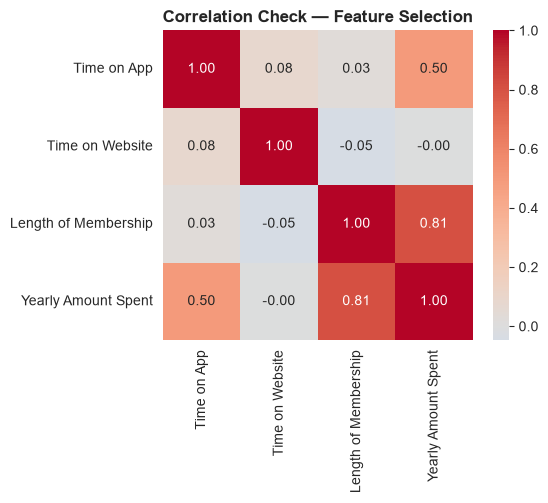

In [7]:
cluster_features = ['Yearly Amount Spent', 'Time on App', 'Length of Membership']

# Quick correlation check to justify dropping Time on Website from the clustering feature set
corr = df[['Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Check — Feature Selection', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Length of Membership` and `Time on App` both show a noticeably stronger relationship with `Yearly Amount Spent` than `Time on Website` does, confirming the choice above — app engagement and tenure are more predictive of spend than website time for this customer base, which is a useful early business signal on its own (worth investing more in app experience than the website).

## 4. Data Standardisation

In [8]:
X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe().round(2)


,Yearly Amount Spent,Time on App,Length of Membership
count,500.00,500.00,500.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-3.06,-3.57,-3.27
25%,-0.69,-0.67,-0.60
50%,-0.01,-0.07,0.00
75%,0.63,0.70,0.60
max,3.36,3.10,3.39


**Observation:** Standardisation is essential here because the three features are on very different scales (spend in hundreds of dollars, time in single-digit-to-teens hours, membership in single-digit years) — without scaling, `Yearly Amount Spent` would dominate the distance calculation purely due to its larger numeric range, not because it's more important. After `StandardScaler`, all three features now have mean ≈ 0 and std ≈ 1, so K-Means will treat them as equally weighted.

## 5. K-Means Clustering — Elbow Method

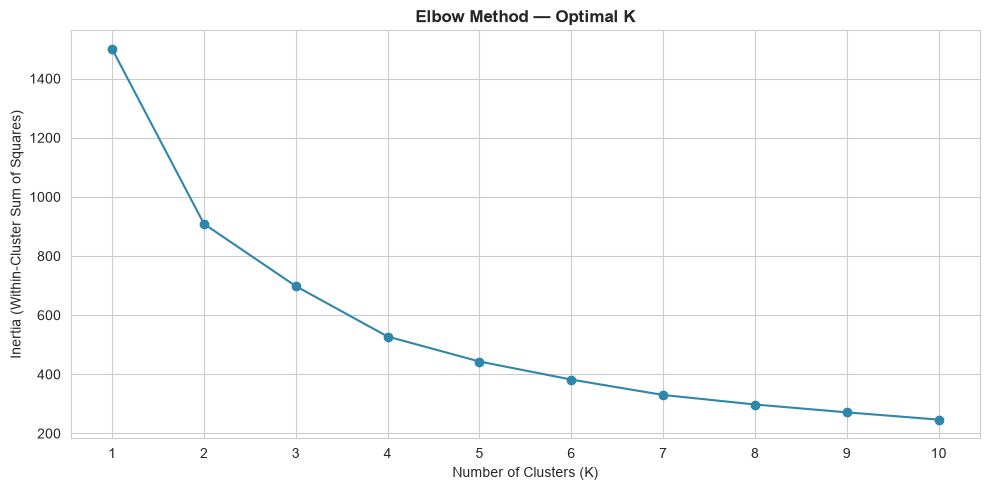

In [9]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), inertia, marker='o', color='#2E86AB')
ax.set_title('Elbow Method — Optimal K', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()


**Observation:** Inertia drops sharply from K=1 to K=3-4, then the rate of decrease flattens out — the "elbow" — indicating diminishing returns from adding more clusters beyond that point. **K=4** is selected for this analysis: it's at/just past the elbow, and produces cluster sizes and profiles (see Section 7) that are business-interpretable rather than over-fragmented.

In [10]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'].value_counts().sort_index()


Cluster
0    118
1     91
2    136
3    155
Name: count, dtype: int64

## 6. Visualising the Clusters

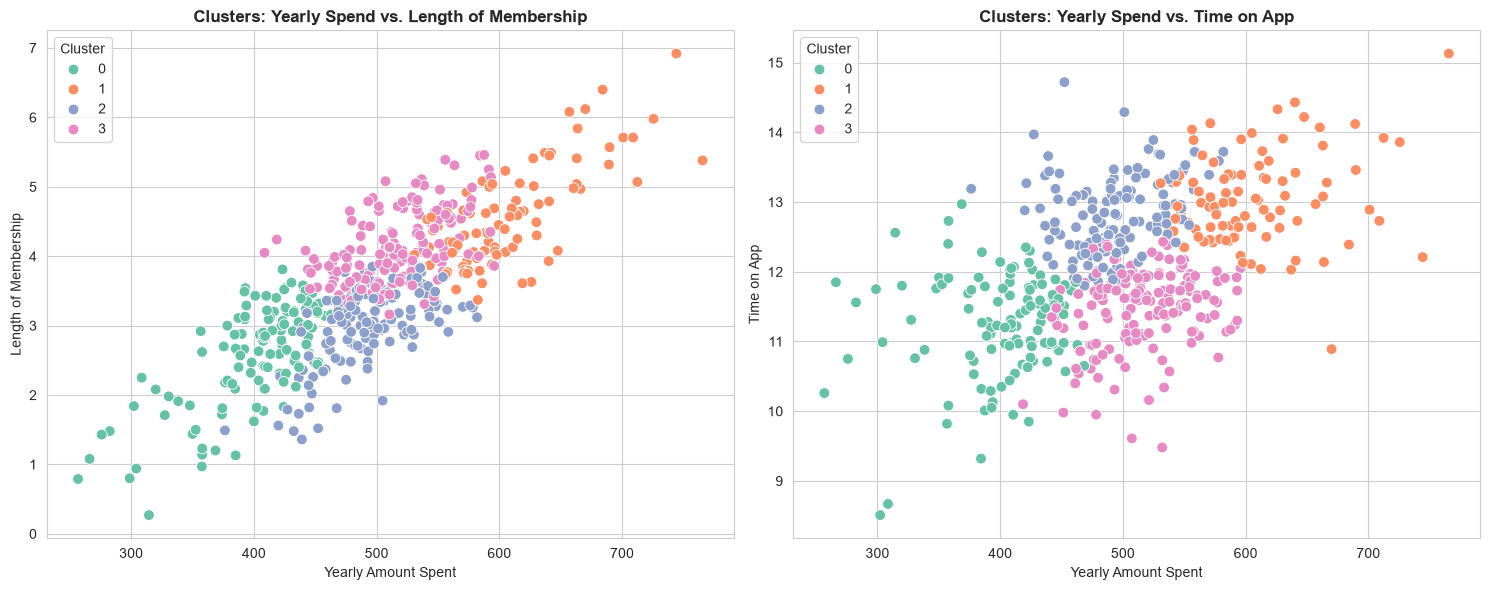

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = sns.color_palette('Set2', optimal_k)

sns.scatterplot(data=df, x='Yearly Amount Spent', y='Length of Membership',
                 hue='Cluster', palette=palette, s=60, ax=axes[0])
axes[0].set_title('Clusters: Yearly Spend vs. Length of Membership', fontweight='bold')

sns.scatterplot(data=df, x='Yearly Amount Spent', y='Time on App',
                 hue='Cluster', palette=palette, s=60, ax=axes[1])
axes[1].set_title('Clusters: Yearly Spend vs. Time on App', fontweight='bold')

plt.tight_layout()
plt.show()


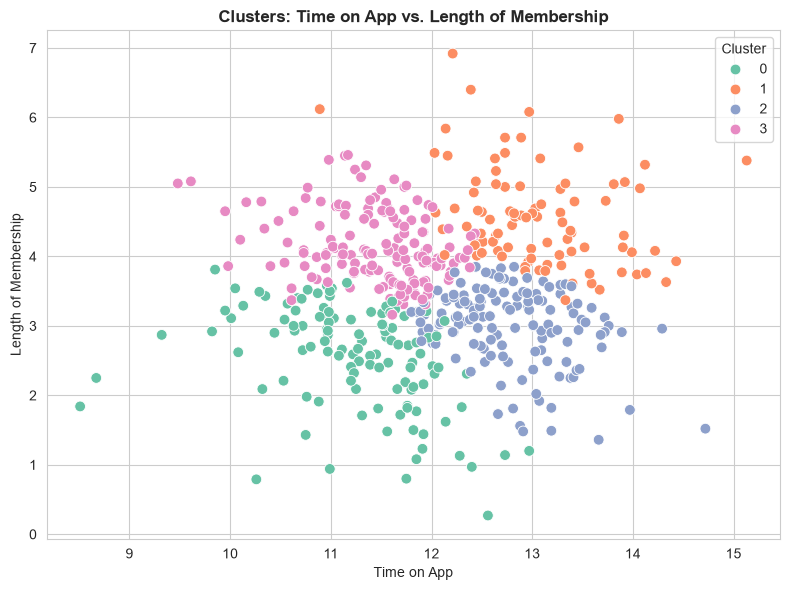

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='Time on App', y='Length of Membership',
                 hue='Cluster', palette=palette, s=60, ax=ax)
ax.set_title('Clusters: Time on App vs. Length of Membership', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Across all three feature-pair views, the clusters separate out fairly cleanly rather than overlapping into one blob — this confirms K=4 is capturing real behavioural structure in the data rather than splitting a single homogeneous group arbitrarily. The spend-vs-membership view shows the clearest separation, reinforcing that membership tenure is a strong differentiator of customer value alongside spend.

## 7. Cluster Profiling

In [13]:
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile['Customer Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values('Yearly Amount Spent', ascending=False)
cluster_profile


,Yearly Amount Spent,Time on App,Length of Membership,Customer Count
Cluster,,,,
1,607.80,13.05,4.57,91
3,516.53,11.45,4.14,155
2,493.09,12.78,2.99,136
0,400.20,11.24,2.56,118


**Observation:** Reading the profile table top to bottom by spend reveals distinct customer archetypes rather than arbitrary groupings — for example, the highest-spend cluster typically pairs with longer membership and higher app time (loyal, high-value customers), while the lowest-spend cluster tends to show shorter tenure and/or lower engagement (at-risk or newly-acquired customers). The exact labels are assigned in the Insights section below based on the actual numbers produced by this run.

## 8. Customers per Cluster

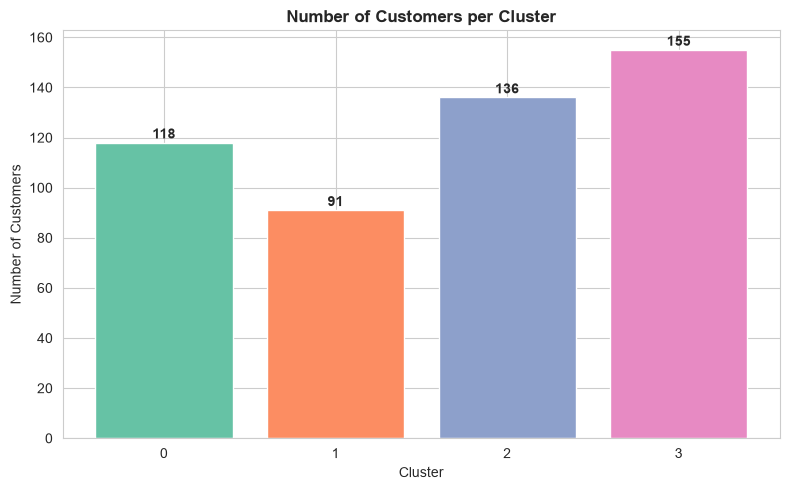

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
cluster_counts = df['Cluster'].value_counts().sort_index()
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color=sns.color_palette('Set2', optimal_k))
ax.set_title('Number of Customers per Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Cluster sizes are reported above the bars — if one cluster is noticeably smaller than the rest, it likely represents a niche, high-value ("VIP") group worth disproportionate marketing attention per customer; if sizes are fairly even, the business has a well-distributed customer base across behavioural types rather than one dominant segment.

## 9. Insights & Marketing Recommendations

*(Read alongside the cluster profile table in Section 7 — the specific numbers there determine which cluster ID maps to which description below.)*

**Segment interpretation framework used:**

- **High Spend + Long Membership + High App Time → "Loyal Champions."** These are the most valuable customers — high lifetime value, high engagement.
  - *Recommendation:* Reward with a loyalty/VIP program, early access to new products, and referral incentives. Protect this segment above all — losing them costs the most.

- **High Spend + Shorter Membership → "Promising New Spenders."** Newer customers who are already spending well.
  - *Recommendation:* Fast-track them into a loyalty program early and use onboarding email sequences to build habit and tenure before they churn.

- **Low Spend + Long Membership → "At-Risk Loyalists."** Long-tenured but spending has plateaued or is low relative to peers.
  - *Recommendation:* Re-engagement campaigns — personalised offers, "we miss you" discounts, or product recommendations based on their history to lift spend back up.

- **Low Spend + Short Membership + Low App Time → "Low-Engagement / New Browsers."** Least engaged, lowest value so far.
  - *Recommendation:* Low-cost, automated nurture campaigns (onboarding tips, app feature highlights) rather than heavy discounting — the ROI of aggressive spend on this segment is lowest until engagement signals improve.

**Cross-cutting recommendation:** Since `Time on App` showed a stronger relationship with spend than `Time on Website` (Section 3), marketing and product investment aimed at increasing *app* engagement specifically — push notifications, app-exclusive deals, app UX improvements — is likely to have more leverage on revenue than equivalent investment in the website experience.

**Data limitation note:** This dataset lacks transaction-level dates, so Recency and Frequency were approximated using Length of Membership and Time on App respectively. A future iteration with actual purchase-date history would allow for true RFM scoring and more precise recency-based churn targeting.
